In [ ]:
from train3 import make_env_fn
from evaluate import EvalInsulinPolicy, evaluate_insulin_policy
import argparse
import json
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback, EvalCallback
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor


patient="adult#001"
meals = "7:45,12:70,16:15,18:80,23:10"

meals = [
    (7 * 60, 45.0),
    (12 * 60, 70.0),
    (16 * 60, 15.0),
    (18 * 60, 80.0),
    (23 * 60, 10.0),
]

eval_env = DummyVecEnv([
    make_env_fn(
        env_id="simglucose-spid-eval-v0",
        patient=patient,
        meals=meals,
        max_episode_steps=480,
        seed=None,
        scenario_mode="fixed",
        time_std_multiplier=1,
        include_snacks=True,
        reward_type="smooth",
        warning_window_min=20,
        insulin_tau_min=55,
        sample_time_min=3,
        max_insulin_action=5,
        
    )
])

eval_env = VecMonitor(eval_env)
model = PPO.load("/home/elisalaegs/GGSpeciale/GGSpeciale/simglucose_singlepatient/teacher_models/smooth/adult-002/models/best/best_model.zip", env=eval_env)

c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\gym\envs\registration.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


TypeError: make_env_fn() missing 5 required positional arguments: 'amount_noise_std_fraction', 'actual_time_noise_std_min', 'actual_time_noise_clip_min', 'shield_bg_threshold', and 'use_bb_warmup'

In [18]:
import juliacall
from train3 import make_env_fn
from evaluate import EvalInsulinPolicy, evaluate_insulin_policy
import argparse
import json
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback, EvalCallback
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor


patient="adult#005"
meals = "7:45,12:70,16:15,18:80,23:10"

meals = [
    (7 * 60, 45.0),
    (12 * 60, 70.0),
    (16 * 60, 15.0),
    (18 * 60, 80.0),
    (23 * 60, 10.0),
]

eval_env = DummyVecEnv([
    make_env_fn(
        env_id="simglucose-spid-eval-v0",
        patient=patient,
        meals=meals,
        max_episode_steps=480,
        seed=None,
        scenario_mode="fixed_hb",
        time_std_multiplier=1,
        include_snacks=True,
        reward_type="smooth",
        warning_window_min=20,
        insulin_tau_min=55,
        sample_time_min=3,
        max_insulin_action=5,
        amount_noise_std_fraction=0,
        actual_time_noise_clip_min=0,
        actual_time_noise_std_min=0,
        use_bb_warmup=False,
        shield_bg_threshold=10
        
    )
])

# import os 
# print(os.getcwd())
# os.chdir("../code/SPID_code")

from PySRWrapper import PySRPolicy


model = PySRPolicy.load(
    "/home/elisalaegs/GGSpeciale/GGSpeciale/simglucose_singlepatient/distil_results/strict/adult-005/best_student_policy.joblib"
)

Policy loaded


HISTORY CLEARED
Evaluating insulin policy...


/faststorage/project/GGSpeciale/GGSpeciale/simglucose_singlepatient/evaluate.py:275: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  history_df = pd.concat(history_list, axis=0, keys=range(len(history_list)))


Generating simglucose report...


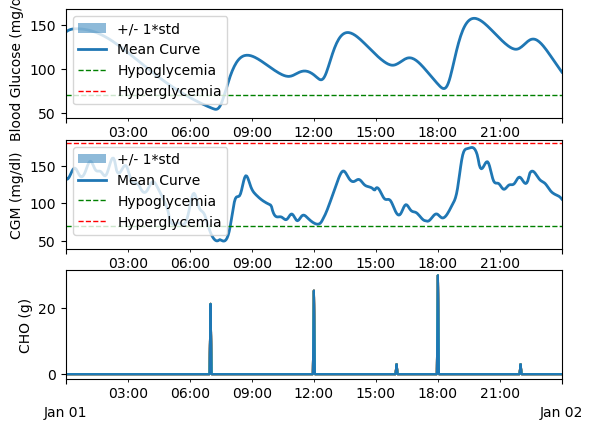

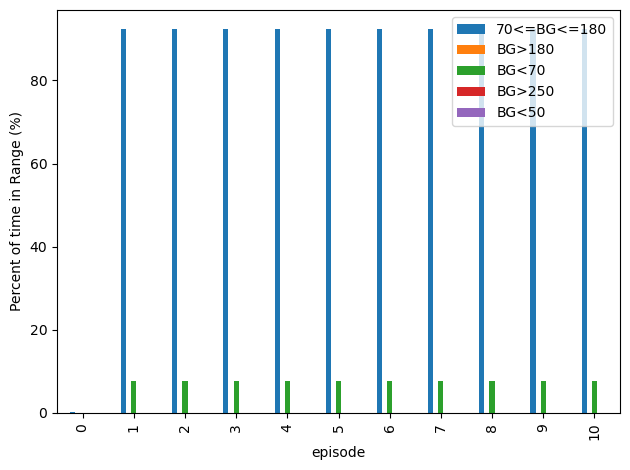

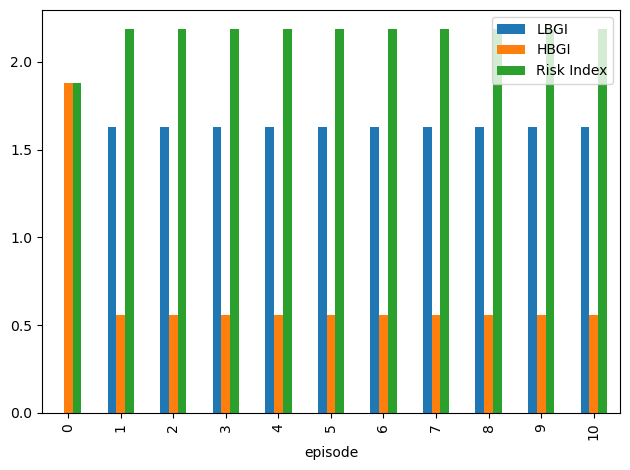

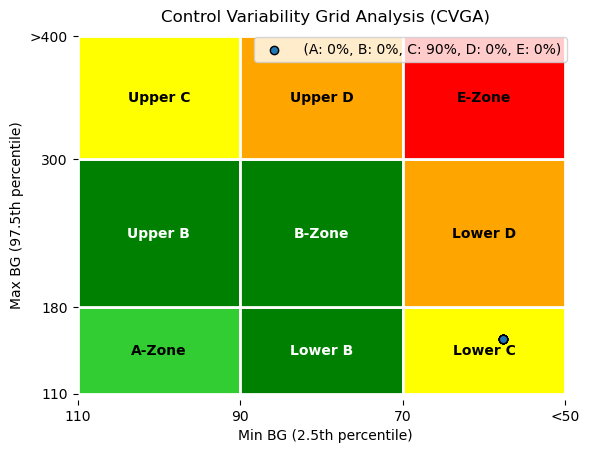

HISTORY CLEARED


{'metrics': {'eval_index': 0,
  'TBR_II': 0.0,
  'TBR_I': 7.708333333333334,
  'TIR': 92.29166666666667,
  'TAR_I': 0.0,
  'TAR_II': 0.0,
  'total_daily_insulin': 32.48005833333333,
  'average_insulin': 0.06766678819444445,
  'critical_failure_rate': 9.090909090909092,
  'num_timesteps': None,
  'mean_reward': 1092.9899433478713,
  'std_reward': 0.0,
  'n_eval_episodes': 10},
 'episode_rewards': [np.float64(1092.9899433478713),
  np.float64(1092.9899433478713),
  np.float64(1092.9899433478713),
  np.float64(1092.9899433478713),
  np.float64(1092.9899433478713),
  np.float64(1092.9899433478713),
  np.float64(1092.9899433478713),
  np.float64(1092.9899433478713),
  np.float64(1092.9899433478713),
  np.float64(1092.9899433478713)],
 'episode_lengths': [np.int64(480),
  np.int64(480),
  np.int64(480),
  np.int64(480),
  np.int64(480),
  np.int64(480),
  np.int64(480),
  np.int64(480),
  np.int64(480),
  np.int64(480)],
 'history':               eval_index                Time          BG   

In [19]:
evaluate_insulin_policy(model, eval_env, save_path="./logs/test/",n_eval_episodes=10, deterministic=False,)

In [4]:

evalCallback = EvalInsulinPolicy(eval_env, 
                                 eval_freq=1, 
                                 n_eval_episodes=20, 
                                 deterministic=False)

model.learn(
    total_timesteps=1,
    callback=[
        evalCallback,
    ],
    progress_bar=True
)

NameError: name 'EvalInsulinPolicy' is not defined